# Прогноз потока кандидатов 2025-2027: EDA

## Описание задачи
Датасет содержит HR-метрики и данные о найме IT-специалистов
в 505 департаментах крупной компании за 2020-2024 гг.

**Цель:** предсказать суммарный поток кандидатов до 2027 года
для планирования нагрузки на рекрутинг.

**Целевая переменная:** `yearly_cv_processed` — количество
обработанных резюме в год на департамент.

## Описание данных
| Колонка | Описание |
|---------|----------|
| ``department_id`` | ID департамента |
| ``year`` | Год наблюдения |
| ``tech_stack`` | Тип объекта (аэропорт, стадион и т.д.) |
| ``current_staff_count`` | Текущая численность IT-персонала |
| ``yearly_cv_processed`` | Обработано резюме за год (целевая) |
| ``active_project_count`` | Количество активных проектов |
| ``devs_hired`` / ``devs_fired`` | Нанято / уволено разработчиков |
| ``turnover_rate`` | Коэффициент текучести кадров |
| ``avg_dev_salary`` | Средняя зарплата разработчика |
| ``total_salary_budget`` | Общий бюджет на зарплаты |
| ``tech_brand_rating`` | Рейтинг технического бренда |
| ``inbound_application`` | Входящие заявки |
| ``share_seniors`` | Доля сеньоров |

## Структура ноутбука
1. EDA — разведочный анализ и чистка данных
2. Feature Engineering — создание признаков

Этот ноутбук - исследование данных. Итоговая очистка и построение признаков реализованы в ``src/data.py`` 

Моделирование и прогноз находятся в ``02_modeling.ipynb``

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import pandas as pd
import phik

from src.data import load_data
from src.eda import overview, show_department
from src.viz import (
    visualize_categorical_overview, visualize_numeric_overview,
    plot_correlation_heatmap,
)
from src import config

In [3]:
data = load_data()
data_raw = load_data()

# EDA

In [4]:
overview(data, name='Сырые данные', stats=True)

== Сырые данные ==
Полных дублей: 0


,тип,пропусков,%,уникальных,пример
department_id,float64,1,0.0,505,1000000.0
year,float64,1,0.0,5,2020.0
tech_stack,object,1,0.0,15,Стадион
current_staff_count,float64,19,0.8,336,392.0
yearly_cv_processed,float64,8,0.3,1876,5847.0
share_seniors,float64,22,0.9,1564,4.591837
active_projects_count,float64,8,0.3,220,231.0
inbound_applications,float64,37,1.5,1173,1969.0
avg_dev_salary,float64,19,0.8,2507,110277.784723
devs_hired,float64,26,1.0,100,77.0


,count,mean,std,min,25%,50%,75%,max
department_id,2525.0,1.000252e+06,1.458095e+02,1.000000e+06,1.000126e+06,1.000252e+06,1.000378e+06,1.000504e+06
year,2525.0,2.022000e+03,1.414494e+00,2.020000e+03,2.021000e+03,2.022000e+03,2.023000e+03,2.024000e+03
current_staff_count,2507.0,1.384340e+02,7.431843e+01,1.000000e+01,8.600000e+01,1.260000e+02,1.755000e+02,6.370000e+02
yearly_cv_processed,2518.0,2.132995e+03,1.276934e+03,4.100000e+01,1.235000e+03,1.957500e+03,2.761250e+03,1.075400e+04
share_seniors,2504.0,2.439117e+01,7.315247e+00,3.333333e+00,1.987137e+01,2.431970e+01,2.871287e+01,6.896552e+01
active_projects_count,2518.0,8.161477e+01,4.520726e+01,2.000000e+00,5.000000e+01,7.600000e+01,1.040000e+02,3.940000e+02
inbound_applications,2489.0,7.027272e+02,7.007512e+02,0.000000e+00,3.700000e+02,5.770000e+02,8.890000e+02,1.722600e+04
avg_dev_salary,2507.0,1.267013e+05,1.640449e+04,4.680017e+04,1.154854e+05,1.249865e+05,1.355210e+05,2.056626e+05
devs_hired,2500.0,1.635920e+01,1.524847e+01,1.000000e+00,8.000000e+00,1.300000e+01,2.000000e+01,1.530000e+02
devs_fired,2499.0,1.684154e+01,1.145180e+01,1.000000e+00,1.000000e+01,1.500000e+01,2.100000e+01,1.290000e+02


,department_id,year,tech_stack,current_staff_count,yearly_cv_processed,share_seniors,active_projects_count,inbound_applications,avg_dev_salary,devs_hired,devs_fired,turnover_rate,tech_brand_rating,total_salary_budget
0,1000000.0,2020.0,Стадион,392.0,5847.0,4.591837,231.0,1969.0,110277.784723,77.0,52.0,0.329082,0.6,51877245.0
1,1000000.0,2021.0,Стадион,445.0,6688.0,6.292135,258.0,2415.0,123862.871896,119.0,47.0,0.373034,0.6,66162037.0
2,1000000.0,2022.0,Стадион,514.0,7503.0,7.198444,291.0,2544.0,122932.673766,143.0,60.0,0.394942,0.6,75827728.0
3,1000000.0,2023.0,Стадион,587.0,8272.0,8.858603,327.0,3426.0,123735.907223,103.0,63.0,0.282794,0.8,87165251.0
4,1000000.0,2024.0,Стадион,632.0,9267.0,11.550633,362.0,3318.0,141861.433957,91.0,96.0,0.295886,0.2,107592482.0


Есть пропуски в следующих столбцах:

- current_staff_count
- yearly_cv_processed
- share_seniors
- active_project_count
- inbound_application
- avg_dev_salary
- devs_hired
- devs_fired
- turnover_rate
- total_salary_budget

Есть только один нечисловой признак - tech_stack

In [5]:
data[data['department_id'].isna() == True]

,department_id,year,tech_stack,current_staff_count,yearly_cv_processed,share_seniors,active_projects_count,inbound_applications,avg_dev_salary,devs_hired,devs_fired,turnover_rate,tech_brand_rating,total_salary_budget
2525,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Думаю, что целевой переменной следует выбрать yearly_cv_processed, поскольку она показывает нагрузку на рекрутинг - количество обработанных заявок за год

Видно, что есть большое различие между третьим квартилем и максимальным значением в current_staff_count, yearly_cv_processed, share_seniors и других признаках. Это говорит о том, что есть разные департаменты, у которых работа слишком сильно различается.

Из странного максимальное значение текучки кадров >1. Вернемся к этому попозже

Должно быть 2525 значений, но у нас их 2526, проверим эту строку

Есть полностью пустая строка, ее удалим

In [6]:
data = data[data['department_id'].isna() == False]
data.shape

(2525, 14)

Отдельно посмотрим на выбранную целевую переменную

In [7]:
data.pivot_table('yearly_cv_processed', 'year', aggfunc='sum')

,yearly_cv_processed
year,
2020.0,995513.0
2021.0,1049537.0
2022.0,1087234.0
2023.0,1112104.0
2024.0,1126493.0


Видим увеличение нагрузки, но темп затухающий

Проверим корреляцию целевой переменной с другими признаками

In [8]:
data.drop('tech_stack', axis=1).corr()['yearly_cv_processed'].sort_values(ascending=False)

yearly_cv_processed      1.000000
active_projects_count    0.978552
current_staff_count      0.944365
total_salary_budget      0.941416
inbound_applications     0.634184
tech_brand_rating        0.558989
devs_fired               0.551819
devs_hired               0.531304
avg_dev_salary           0.317125
year                     0.067630
share_seniors           -0.032118
department_id           -0.054398
turnover_rate           -0.144520
Name: yearly_cv_processed, dtype: float64

Больше всего влияет:

- active_projects_count
- current_staff_count
- total_salary_budget

Это логично, поскольку если много активных проектов -> нужны сотрудники -> растет нагрузка на рекрутинг

Проверим пропуски подробнее (дубликаты уже видно в сводке overview выше - их нет)

In [9]:
data.isna().sum()

department_id             0
year                      0
tech_stack                0
current_staff_count      18
yearly_cv_processed       7
share_seniors            21
active_projects_count     7
inbound_applications     36
avg_dev_salary           18
devs_hired               25
devs_fired               26
turnover_rate            18
tech_brand_rating         0
total_salary_budget      29
dtype: int64

Думаю, стоит заменить значения на медианные по департаменту

In [10]:
num_cols = data.select_dtypes(include='number').columns

data[num_cols] = data[num_cols].fillna(
    data.groupby('department_id')[num_cols].transform('median')
)
data.isna().sum()

department_id            0
year                     0
tech_stack               0
current_staff_count      0
yearly_cv_processed      0
share_seniors            0
active_projects_count    0
inbound_applications     0
avg_dev_salary           0
devs_hired               0
devs_fired               5
turnover_rate            0
tech_brand_rating        0
total_salary_budget      0
dtype: int64

In [11]:
data[data['devs_fired'].isna()]

,department_id,year,tech_stack,current_staff_count,yearly_cv_processed,share_seniors,active_projects_count,inbound_applications,avg_dev_salary,devs_hired,devs_fired,turnover_rate,tech_brand_rating,total_salary_budget
2280,1000456.0,2020.0,Учебное_заведение,24.0,132.0,20.833333,6.0,49.0,109048.97,1.0,NaN,0.000000,0.0,2352992.0
2281,1000456.0,2021.0,Учебное_заведение,22.0,100.0,13.636364,4.0,37.0,109048.97,1.0,NaN,0.000000,0.0,2352992.0
2282,1000456.0,2022.0,Учебное_заведение,20.0,76.0,10.000000,3.0,39.0,109048.97,1.0,NaN,0.000000,0.0,2352992.0
2283,1000456.0,2023.0,Учебное_заведение,19.0,71.0,15.789474,3.0,43.0,109048.97,1.0,NaN,0.000000,0.0,2352992.0
2284,1000456.0,2024.0,Учебное_заведение,18.0,74.0,11.111111,3.0,46.0,109048.97,1.0,NaN,0.055556,0.0,2352992.0


Все пропуски в одном департаменте. Из странного - количество сотрудников меняется, но отсутствует информация об уволенных сотрудников. Также есть проблема с turnoner_rate - значение 0.

Гипотеза: уволенных можно восстановить из баланса штата - devs_fired = prev_stuff_count + devs_hired - current_staff. Проверим ее на строках, где devs_fired известен

In [12]:
check = data_raw.sort_values(by=['department_id', 'year']).copy()

check['prev_staff_count'] = check.groupby('department_id')['current_staff_count'].shift(1)

check.dropna(subset=['current_staff_count', 'devs_fired', 'devs_hired', 'prev_staff_count'], inplace=True)
check['devs_fired_check'] = check['prev_staff_count'] + check['devs_hired'] - check['current_staff_count']

sum(check['devs_fired_check'] == check['devs_fired'])

90

In [13]:
check['devs_fired_check'].describe()

count    1976.000000
mean       14.601215
std        18.715481
min      -318.000000
25%         6.000000
50%        13.000000
75%        20.000000
max       349.000000
Name: devs_fired_check, dtype: float64

In [14]:
check['devs_fired_delta'] = check['devs_fired_check'] - check['devs_fired'] 

check['devs_fired_delta'].describe()

count    1976.000000
mean       -3.066802
std        17.491541
min      -326.000000
25%        -9.000000
50%        -2.000000
75%         3.000000
max       333.000000
Name: devs_fired_delta, dtype: float64

Рассмотрел ``devs_fired``. Увидели, что значения по формуле devs_fired = prev_staff_count + devs_hired - current_staff_count совпадают с известными только в 5%. Расхождения от -326 до 333. 

Пропуски в ``devs_fired`` заполняются медианой департамента, а если нет ни одного известного значения - штатом, умноженным на медианную долю увольнений по всем департаментам

In [15]:
known = data_raw[['devs_fired', 'current_staff_count']].dropna()
fire_rate = (known['devs_fired'] / known['current_staff_count']).median()
print(f'Медианная доля увольнений: {fire_rate:.3f}')

no_history = data['devs_fired'].isna()
data.loc[no_history, 'devs_fired'] = (data.loc[no_history, 'current_staff_count'] * fire_rate).round()
show_department(data, 1000456.0)

Медианная доля увольнений: 0.117


,department_id,year,tech_stack,current_staff_count,yearly_cv_processed,share_seniors,active_projects_count,inbound_applications,avg_dev_salary,devs_hired,devs_fired,turnover_rate,tech_brand_rating,total_salary_budget
2280,1000456.0,2020.0,Учебное_заведение,24.0,132.0,20.833333,6.0,49.0,109048.97,1.0,3.0,0.000000,0.0,2352992.0
2281,1000456.0,2021.0,Учебное_заведение,22.0,100.0,13.636364,4.0,37.0,109048.97,1.0,3.0,0.000000,0.0,2352992.0
2282,1000456.0,2022.0,Учебное_заведение,20.0,76.0,10.000000,3.0,39.0,109048.97,1.0,2.0,0.000000,0.0,2352992.0
2283,1000456.0,2023.0,Учебное_заведение,19.0,71.0,15.789474,3.0,43.0,109048.97,1.0,2.0,0.000000,0.0,2352992.0
2284,1000456.0,2024.0,Учебное_заведение,18.0,74.0,11.111111,3.0,46.0,109048.97,1.0,2.0,0.055556,0.0,2352992.0


Получили 2-3 увольнения при штаты 18-24 - правдоподобно

In [16]:
data.isna().sum().sum()

np.int64(0)

Пропусков больше нет

Разберемся с turnover_rate, посмотрим, где он больше единицы

In [17]:
data[data['turnover_rate'] > 1][['department_id', 'tech_stack', 'year',
      'current_staff_count', 'devs_fired', 'devs_hired', 'turnover_rate']]

,department_id,tech_stack,year,current_staff_count,devs_fired,devs_hired,turnover_rate
235,1000047.0,Спальный_район,2020.0,158.0,125.0,120.0,1.550633
236,1000047.0,Спальный_район,2021.0,163.0,129.0,124.0,1.552147
237,1000047.0,Спальный_район,2022.0,147.0,117.0,113.0,1.564626
238,1000047.0,Спальный_район,2023.0,186.0,121.0,117.0,1.279570
239,1000047.0,Спальный_район,2024.0,173.0,113.0,112.0,1.300578
1028,1000205.0,ЖД_станция,2023.0,47.0,19.0,40.0,1.255319
1135,1000227.0,Туристический_центр,2020.0,166.0,16.0,153.0,1.018072
1317,1000263.0,Жилой_район,2022.0,29.0,15.0,18.0,1.137931
1319,1000263.0,Жилой_район,2024.0,27.0,27.0,10.0,1.370370
1346,1000269.0,Туристический_центр,2021.0,90.0,11.0,83.0,1.044444


После проверки понял, какая формула используется для значения turnover_rate. Но нужно ее перезаписать для исправленных значений

In [18]:
data['turnover_rate'] = (data['devs_fired'] + data['devs_hired']) / data['current_staff_count']

In [19]:
print('Описание до')
print(data_raw['turnover_rate'].describe())
print('Описание после:')
print(data['turnover_rate'].describe())

Описание до
count    2507.000000
mean        0.246202
std         0.137675
min         0.000000
25%         0.163082
50%         0.220000
75%         0.297872
max         1.564626
Name: turnover_rate, dtype: float64
Описание после:
count    2525.000000
mean        0.249072
std         0.139156
min         0.025830
25%         0.164251
50%         0.222222
75%         0.300000
max         1.564626
Name: turnover_rate, dtype: float64


Описательная статистика немого поменялась, минимальное значение теперь не 0 - это главное

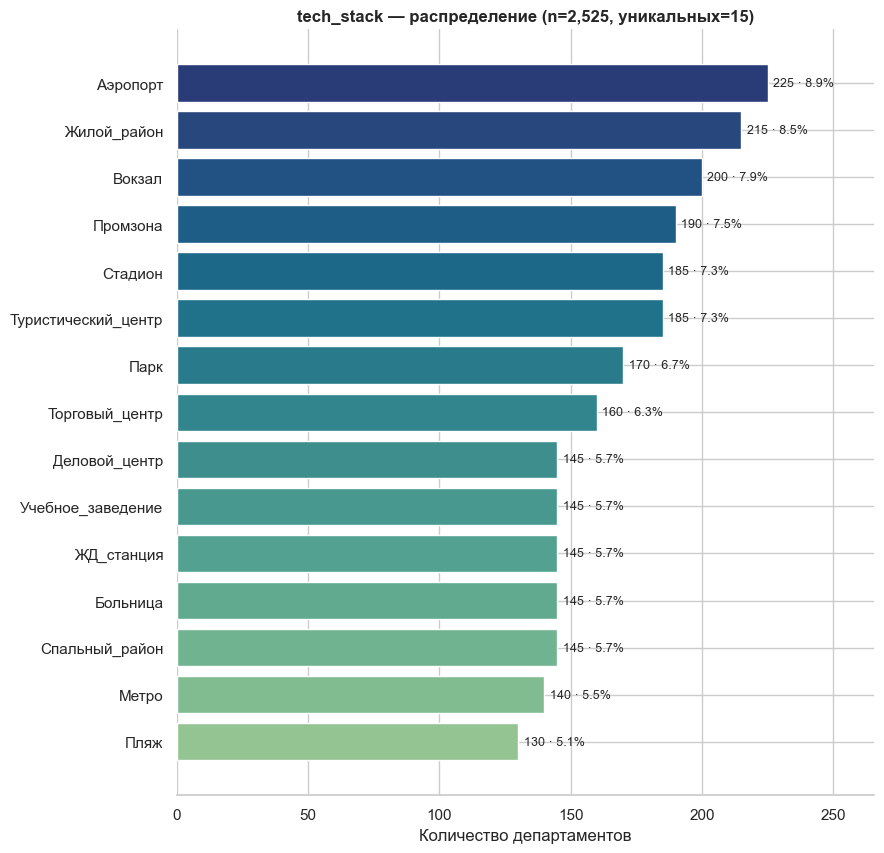

In [20]:
visualize_categorical_overview(data, exclude_columns=['department_id'])

Чаще всего в датасете встречаются аэропорты и жилые районы.

Далее идут вокзалы, промзона, туристический центр и стадион, парки и торговые центры

Остальные департаменты представлены примерно в одинаковом количестве

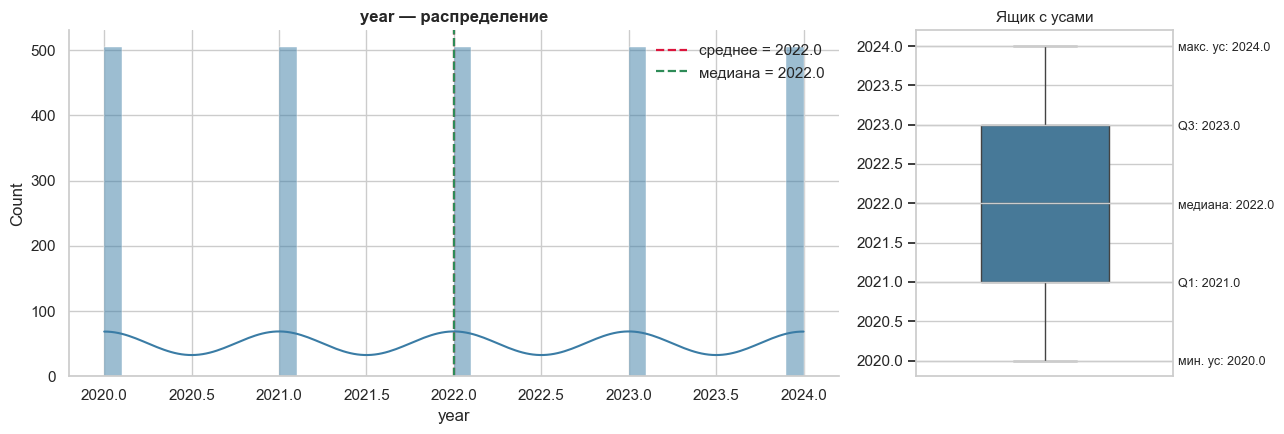

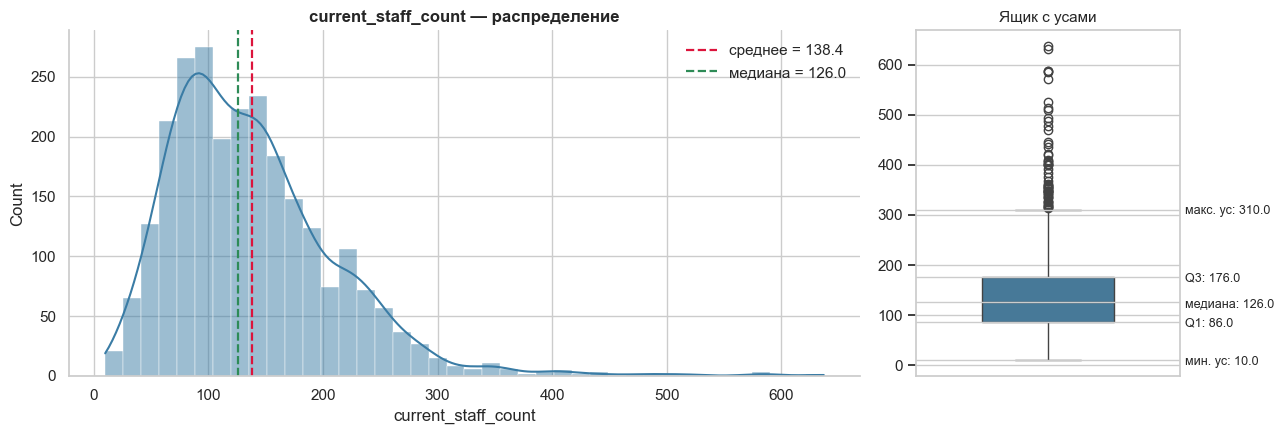

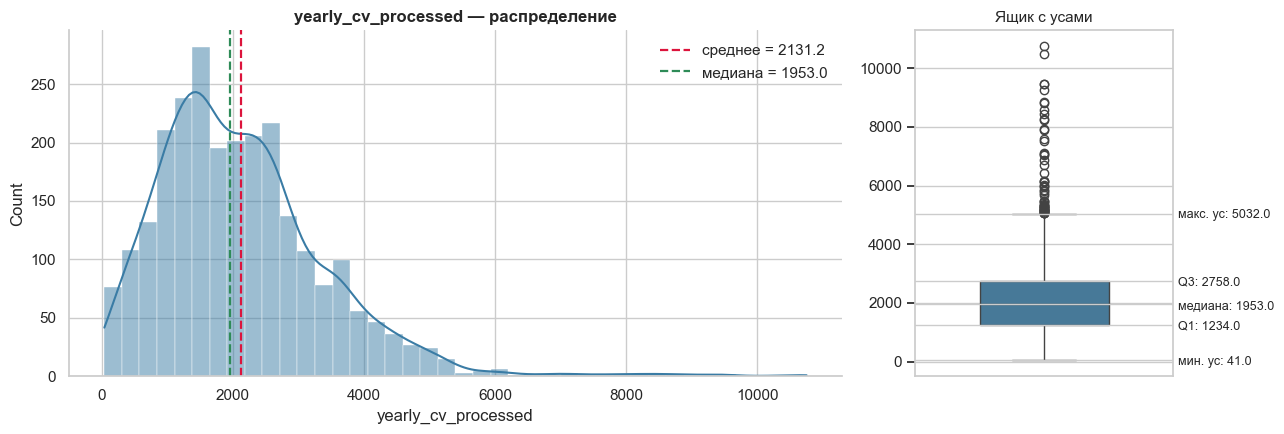

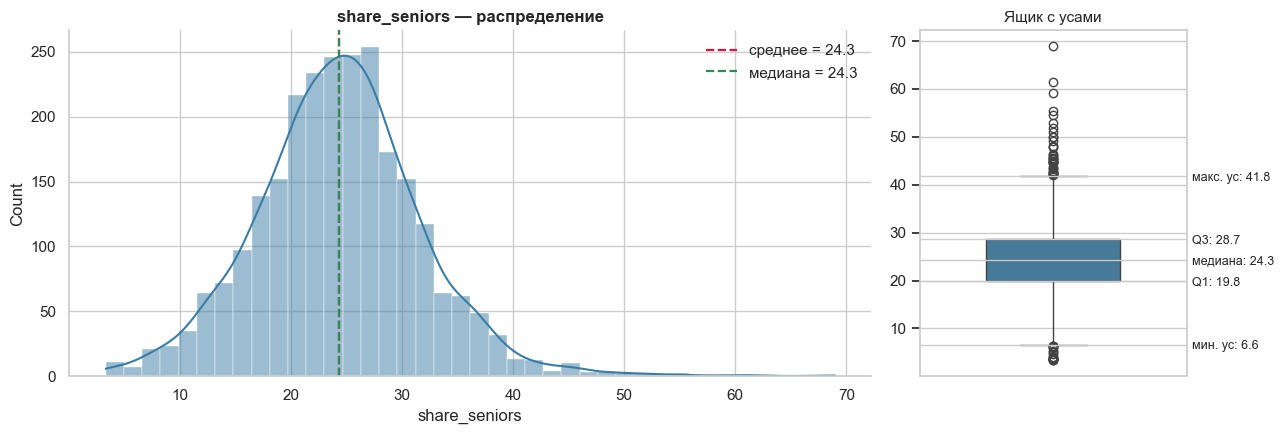

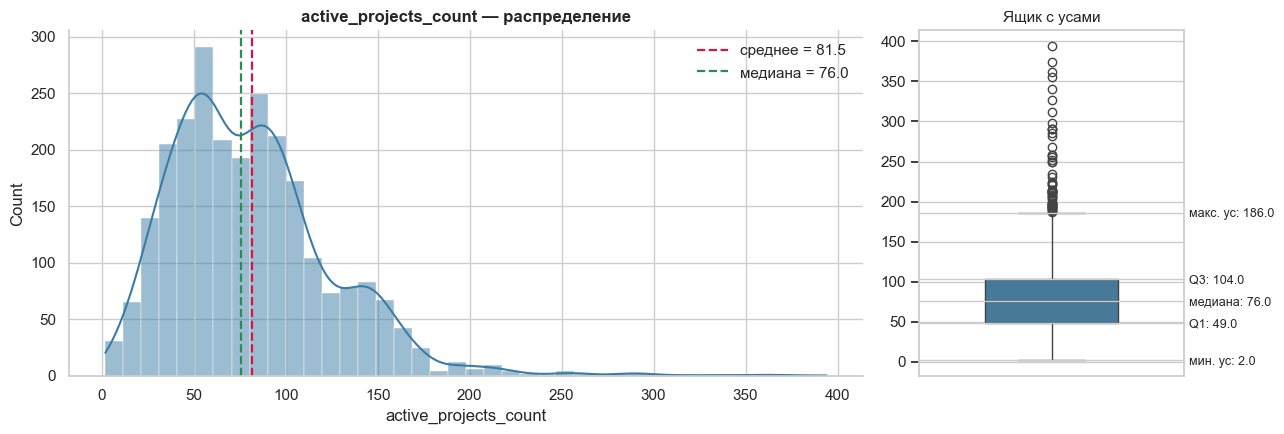

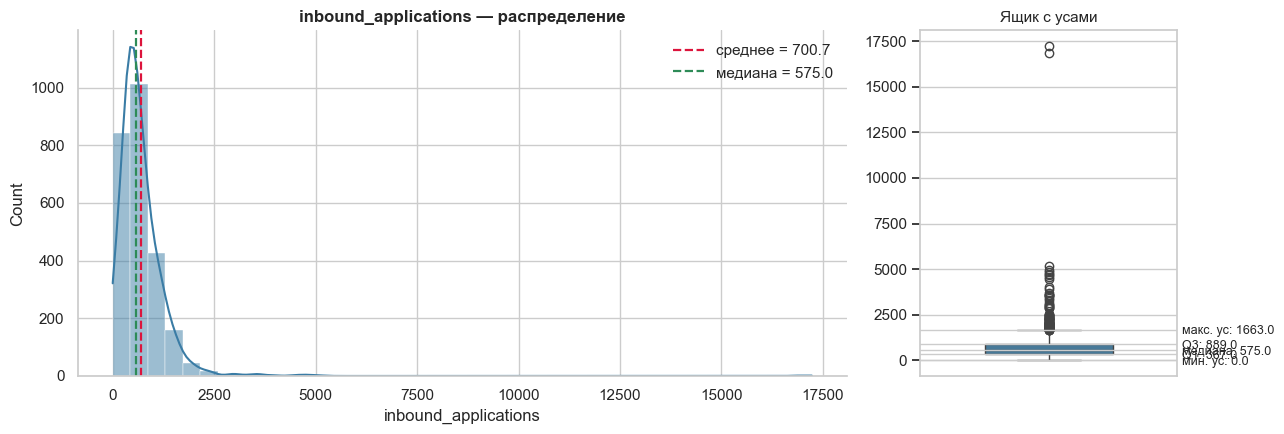

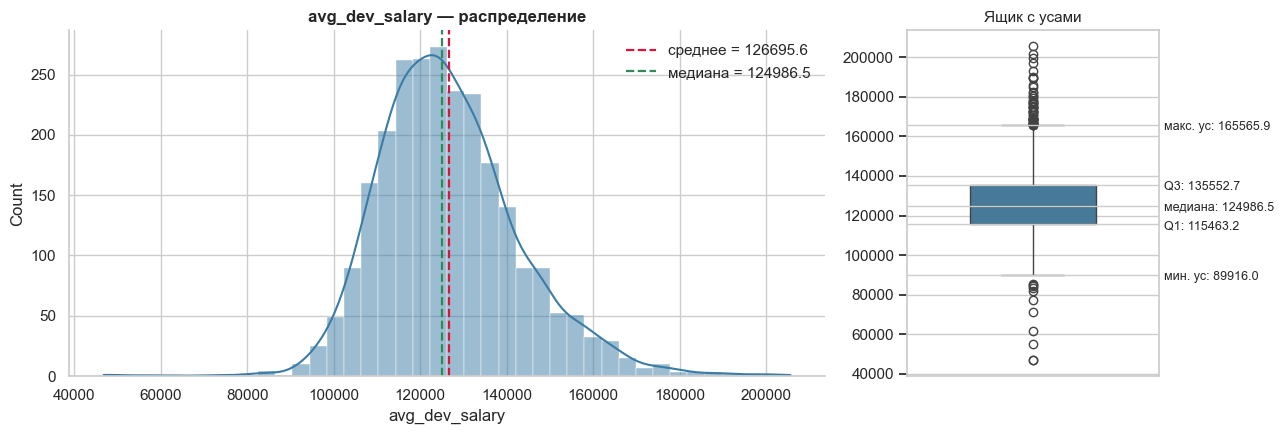

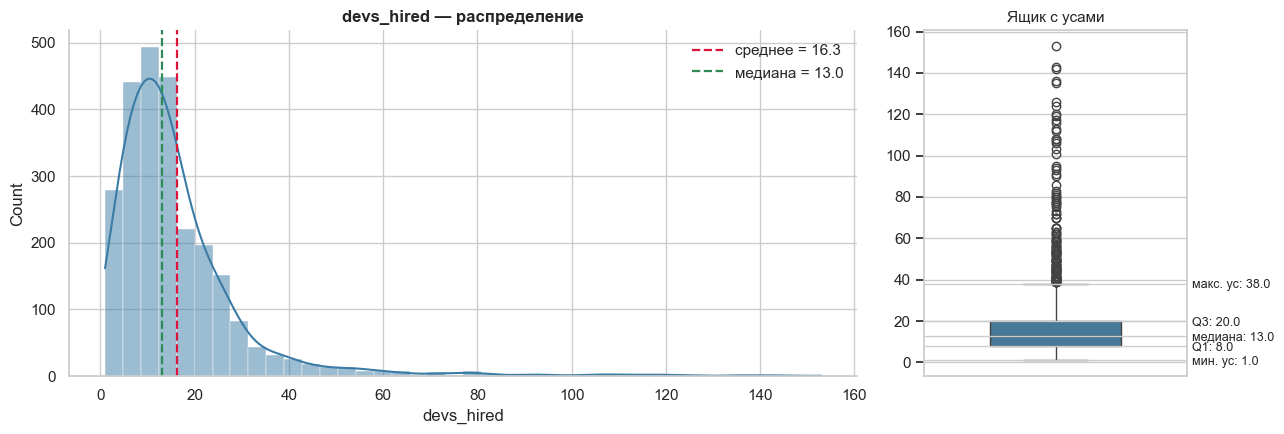

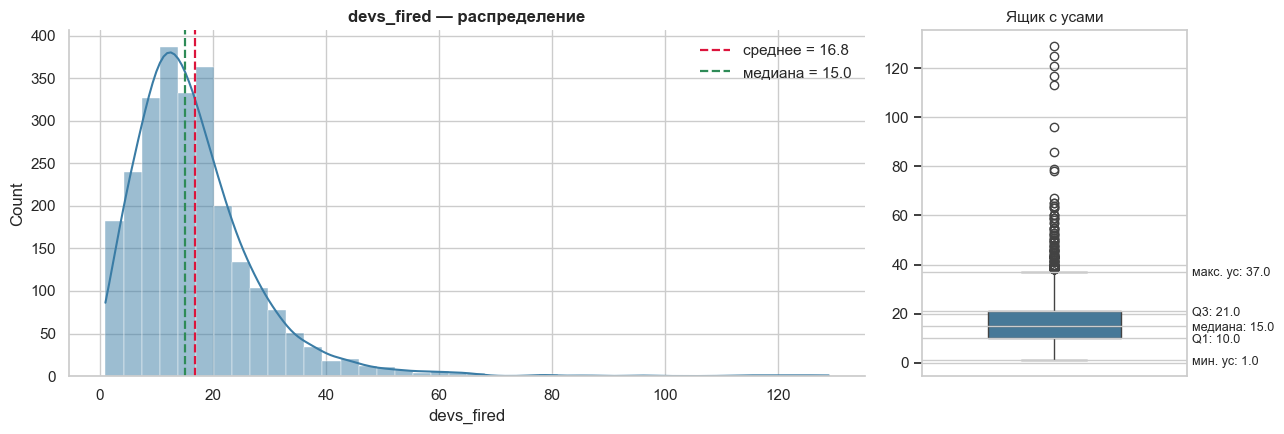

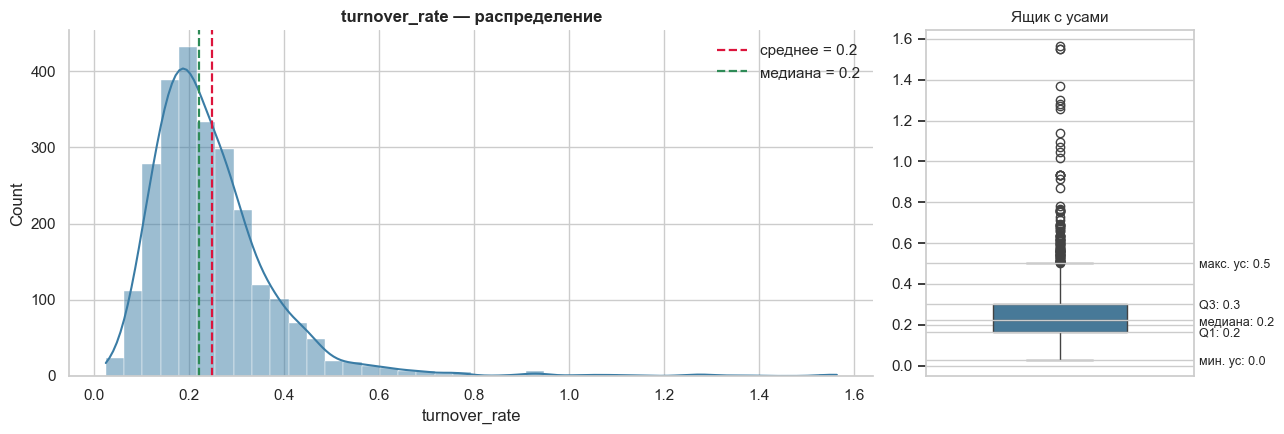

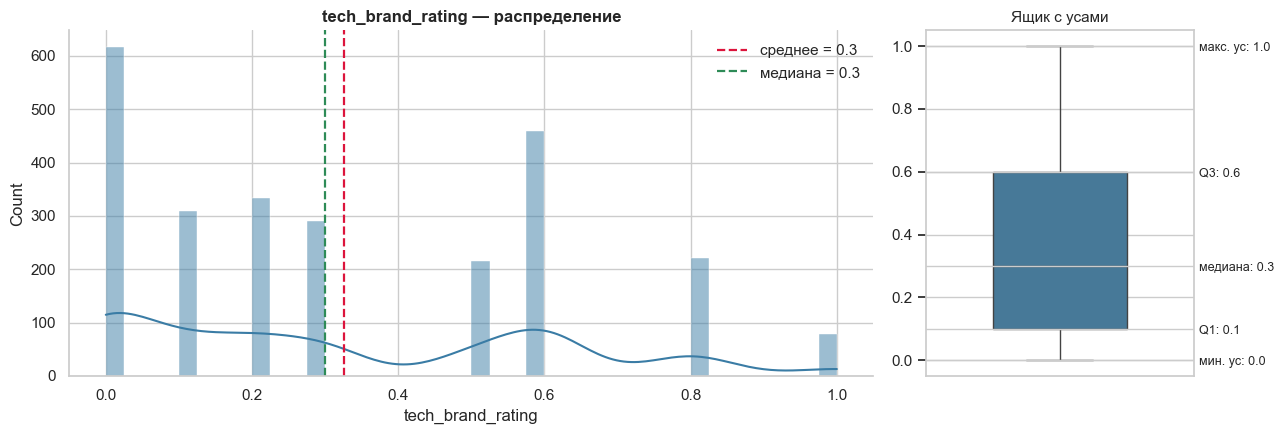

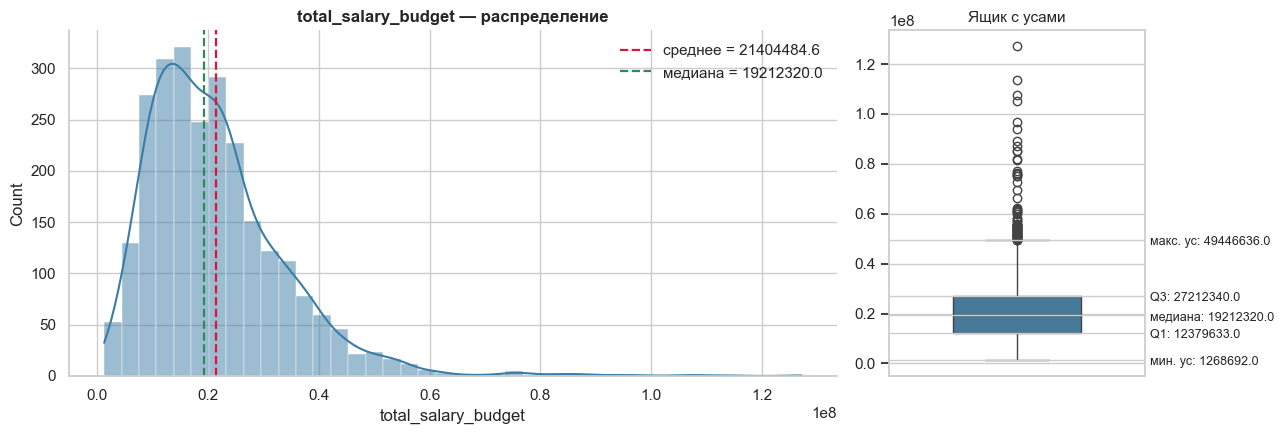

In [21]:
visualize_numeric_overview(data, exclude_columns=['department_id'])

Выводы, которые можно сделать:

- Медианное значение сотрудников в департаменте около 130. Однако встречаются и департаменты в которых более 310 сотрудников.
- От прошлого пункта логично следует, что и нагрузка тоже будет иметь выбросы. Медианное значение обработанных заявок - 2000, но есть и департаменты, у которых более 6000 заявок
- Та же картина в активных проектах. Медианное значение около 80, но есть и департаменты с более чем 200 проектами.
- Есть 2 сильных выброса в количестве входящих заявок. Медианное значение около 500, но выбросы выше 15000.
- Распределение средней зарплаты разработчика близко к нормальному. Есть выбросы как в меньшую, так и в большую сторону.
- Количество нанятых/уволенных разработчиков, в соответствии с тем, что департаменты разной величины, также имеет выбросы.
- Та же картина с turnover_rate
- tech_brand_rating имеет 8 значений

**Итог**

Все, что связано с департаментами, например количество активных проектов, нагрузка на рекрутинг, количество нанятых сотрудников, имеют выбросы, поскольку департаменты разной величины

Зарплата имеет распределение близкое к нормальной, поскольку это рыночная характеристика

Рассмотрим подробнее на выбросы

Сначала посмотрим на департаменты, в которых более 300 сотрудников

In [22]:
data[data['current_staff_count'] > 300]['tech_stack'].value_counts()

tech_stack
Стадион                15
Торговый_центр         11
Учебное_заведение       6
Пляж                    5
Аэропорт                5
Деловой_центр           5
Спальный_район          5
Туристический_центр     4
Промзона                3
Метро                   1
Парк                    1
Жилой_район             1
Name: count, dtype: int64

Как мы видим, большинство таких департаментов - стадионы и торговые центры

In [23]:
data.groupby('tech_stack')['turnover_rate'].median().sort_values(ascending=False)

tech_stack
Спальный_район         0.241935
Промзона               0.238513
ЖД_станция             0.234657
Жилой_район            0.234568
Парк                   0.227730
Деловой_центр          0.226190
Метро                  0.225244
Торговый_центр         0.224440
Пляж                   0.222291
Больница               0.220408
Учебное_заведение      0.217391
Туристический_центр    0.215909
Аэропорт               0.212389
Вокзал                 0.206068
Стадион                0.204678
Name: turnover_rate, dtype: float64

Средняя текучка кадров по типам объекта почти не отличается

Посмотрим на выбросы в inbound_applications

In [24]:
data[data['inbound_applications'] > 7500]

,department_id,year,tech_stack,current_staff_count,yearly_cv_processed,share_seniors,active_projects_count,inbound_applications,avg_dev_salary,devs_hired,devs_fired,turnover_rate,tech_brand_rating,total_salary_budget
820,1000164.0,2020.0,Учебное_заведение,155.0,2685.0,24.516129,98.0,17226.0,124340.782976,24.0,26.0,0.322581,0.6,23130453.0
1685,1000337.0,2020.0,Жилой_район,146.0,1801.0,27.397260,88.0,16859.0,117822.232581,8.0,4.0,0.082192,0.0,20641907.0


In [25]:
show_department(data, 1000164.0)

,department_id,year,tech_stack,current_staff_count,yearly_cv_processed,share_seniors,active_projects_count,inbound_applications,avg_dev_salary,devs_hired,devs_fired,turnover_rate,tech_brand_rating,total_salary_budget
820,1000164.0,2020.0,Учебное_заведение,155.0,2685.0,24.516129,98.0,17226.0,124340.782976,24.0,26.0,0.322581,0.6,23130453.0
821,1000164.0,2021.0,Учебное_заведение,154.0,2661.0,19.480519,96.0,865.0,139050.698640,18.0,19.0,0.240260,0.6,25691455.0
822,1000164.0,2022.0,Учебное_заведение,149.0,2572.0,20.805369,93.0,1012.0,119636.882292,18.0,29.0,0.315436,0.6,21389788.0
823,1000164.0,2023.0,Учебное_заведение,149.0,2567.0,24.161074,93.0,1201.0,125092.896076,23.0,18.0,0.275168,0.6,22358267.0
824,1000164.0,2024.0,Учебное_заведение,154.0,2588.0,29.220779,93.0,1041.0,139728.132546,18.0,22.0,0.259740,0.6,25823755.0


Очень странно, почему в учебное заведение в один год поступило настолько много заявок - 17 тыс. в 2020 против 1000 в остальные годы

In [26]:
show_department(data, 1000337.0)

,department_id,year,tech_stack,current_staff_count,yearly_cv_processed,share_seniors,active_projects_count,inbound_applications,avg_dev_salary,devs_hired,devs_fired,turnover_rate,tech_brand_rating,total_salary_budget
1685,1000337.0,2020.0,Жилой_район,146.0,1801.0,27.397260,88.0,16859.0,117822.232581,8.0,4.0,0.082192,0.0,20641907.0
1686,1000337.0,2021.0,Жилой_район,144.0,1821.0,27.777778,92.0,452.0,109817.427949,5.0,7.0,0.083333,0.2,18976010.0
1687,1000337.0,2022.0,Жилой_район,147.0,1806.0,28.571429,91.0,490.0,108863.911623,8.0,7.0,0.102041,0.2,19201744.0
1688,1000337.0,2023.0,Жилой_район,147.0,1776.0,31.972789,91.0,514.0,115206.982584,5.0,11.0,0.108844,0.3,20321218.0
1689,1000337.0,2024.0,Жилой_район,137.0,1690.0,36.496350,82.0,404.0,121983.058791,4.0,5.0,0.065693,0.3,20062008.0


Более странная картина, учитывая, что было нанято всего 8 сотрудников

Думаю, что стоит заменить это значение на медианное

In [27]:
for dept_id in [1000164.0, 1000337.0]:
    idx = (data['department_id'] == dept_id) & (data['year'] == 2020.0)
    median_val = data[data['department_id'] == dept_id]['inbound_applications'].median()
    data.loc[idx, 'inbound_applications'] = median_val

show_department(data, 1000164.0)

,department_id,year,tech_stack,current_staff_count,yearly_cv_processed,share_seniors,active_projects_count,inbound_applications,avg_dev_salary,devs_hired,devs_fired,turnover_rate,tech_brand_rating,total_salary_budget
820,1000164.0,2020.0,Учебное_заведение,155.0,2685.0,24.516129,98.0,1041.0,124340.782976,24.0,26.0,0.322581,0.6,23130453.0
821,1000164.0,2021.0,Учебное_заведение,154.0,2661.0,19.480519,96.0,865.0,139050.698640,18.0,19.0,0.240260,0.6,25691455.0
822,1000164.0,2022.0,Учебное_заведение,149.0,2572.0,20.805369,93.0,1012.0,119636.882292,18.0,29.0,0.315436,0.6,21389788.0
823,1000164.0,2023.0,Учебное_заведение,149.0,2567.0,24.161074,93.0,1201.0,125092.896076,23.0,18.0,0.275168,0.6,22358267.0
824,1000164.0,2024.0,Учебное_заведение,154.0,2588.0,29.220779,93.0,1041.0,139728.132546,18.0,22.0,0.259740,0.6,25823755.0


In [28]:
show_department(data, 1000337.0)

,department_id,year,tech_stack,current_staff_count,yearly_cv_processed,share_seniors,active_projects_count,inbound_applications,avg_dev_salary,devs_hired,devs_fired,turnover_rate,tech_brand_rating,total_salary_budget
1685,1000337.0,2020.0,Жилой_район,146.0,1801.0,27.397260,88.0,490.0,117822.232581,8.0,4.0,0.082192,0.0,20641907.0
1686,1000337.0,2021.0,Жилой_район,144.0,1821.0,27.777778,92.0,452.0,109817.427949,5.0,7.0,0.083333,0.2,18976010.0
1687,1000337.0,2022.0,Жилой_район,147.0,1806.0,28.571429,91.0,490.0,108863.911623,8.0,7.0,0.102041,0.2,19201744.0
1688,1000337.0,2023.0,Жилой_район,147.0,1776.0,31.972789,91.0,514.0,115206.982584,5.0,11.0,0.108844,0.3,20321218.0
1689,1000337.0,2024.0,Жилой_район,137.0,1690.0,36.496350,82.0,404.0,121983.058791,4.0,5.0,0.065693,0.3,20062008.0


Теперь значения стали более реалистичными

Рассмотрим целевую переменную еще раз после преобразований

In [29]:
overview(data, name='Данные после очистки', stats=True)

== Данные после очистки ==
Полных дублей: 0


,тип,пропусков,%,уникальных,пример
department_id,float64,0,0.0,505,1000000.0
year,float64,0,0.0,5,2020.0
tech_stack,object,0,0.0,15,Стадион
current_staff_count,float64,0,0.0,341,392.0
yearly_cv_processed,float64,0,0.0,1878,5847.0
share_seniors,float64,0,0.0,1575,4.591837
active_projects_count,float64,0,0.0,222,231.0
inbound_applications,float64,0,0.0,1184,1969.0
avg_dev_salary,float64,0,0.0,2511,110277.784723
devs_hired,float64,0,0.0,104,77.0


,count,mean,std,min,25%,50%,75%,max
department_id,2525.0,1.000252e+06,1.458095e+02,1.000000e+06,1.000126e+06,1.000252e+06,1.000378e+06,1.000504e+06
year,2525.0,2.022000e+03,1.414494e+00,2.020000e+03,2.021000e+03,2.022000e+03,2.023000e+03,2.024000e+03
current_staff_count,2525.0,1.383887e+02,7.429664e+01,1.000000e+01,8.600000e+01,1.260000e+02,1.760000e+02,6.370000e+02
yearly_cv_processed,2525.0,2.131177e+03,1.275912e+03,4.100000e+01,1.234000e+03,1.953000e+03,2.758000e+03,1.075400e+04
share_seniors,2525.0,2.433280e+01,7.359736e+00,3.333333e+00,1.981567e+01,2.429378e+01,2.867647e+01,6.896552e+01
active_projects_count,2525.0,8.153465e+01,4.518038e+01,2.000000e+00,4.900000e+01,7.600000e+01,1.040000e+02,3.940000e+02
inbound_applications,2525.0,6.878168e+02,5.272648e+02,0.000000e+00,3.670000e+02,5.750000e+02,8.890000e+02,5.167000e+03
avg_dev_salary,2525.0,1.266956e+05,1.639421e+04,4.680017e+04,1.154632e+05,1.249865e+05,1.355527e+05,2.056626e+05
devs_hired,2525.0,1.629782e+01,1.522995e+01,1.000000e+00,8.000000e+00,1.300000e+01,2.000000e+01,1.530000e+02
devs_fired,2525.0,1.677980e+01,1.145338e+01,1.000000e+00,1.000000e+01,1.500000e+01,2.100000e+01,1.290000e+02


,department_id,year,tech_stack,current_staff_count,yearly_cv_processed,share_seniors,active_projects_count,inbound_applications,avg_dev_salary,devs_hired,devs_fired,turnover_rate,tech_brand_rating,total_salary_budget
0,1000000.0,2020.0,Стадион,392.0,5847.0,4.591837,231.0,1969.0,110277.784723,77.0,52.0,0.329082,0.6,51877245.0
1,1000000.0,2021.0,Стадион,445.0,6688.0,6.292135,258.0,2415.0,123862.871896,119.0,47.0,0.373034,0.6,66162037.0
2,1000000.0,2022.0,Стадион,514.0,7503.0,7.198444,291.0,2544.0,122932.673766,143.0,60.0,0.394942,0.6,75827728.0
3,1000000.0,2023.0,Стадион,587.0,8272.0,8.858603,327.0,3426.0,123735.907223,103.0,63.0,0.282794,0.8,87165251.0
4,1000000.0,2024.0,Стадион,632.0,9267.0,11.550633,362.0,3318.0,141861.433957,91.0,96.0,0.295886,0.2,107592482.0


Пропусков не осталось, аномалии в devs_fired, turnover_rate и inbound_applications исправлены - `overview` показывает то же самое, что и в начале, но уже на чистых данных

In [30]:
data.pivot_table('yearly_cv_processed', 'year', aggfunc='sum')

,yearly_cv_processed
year,
2020.0,1000442.0
2021.0,1052243.0
2022.0,1089940.0
2023.0,1112104.0
2024.0,1126493.0


Рассмотрим изменения

In [31]:
data.groupby('year')['yearly_cv_processed'].sum().pct_change() * 100

year
2020.0         NaN
2021.0    5.177811
2022.0    3.582537
2023.0    2.033506
2024.0    1.293854
Name: yearly_cv_processed, dtype: float64

Как и говорилось ранее, тренд затухающий

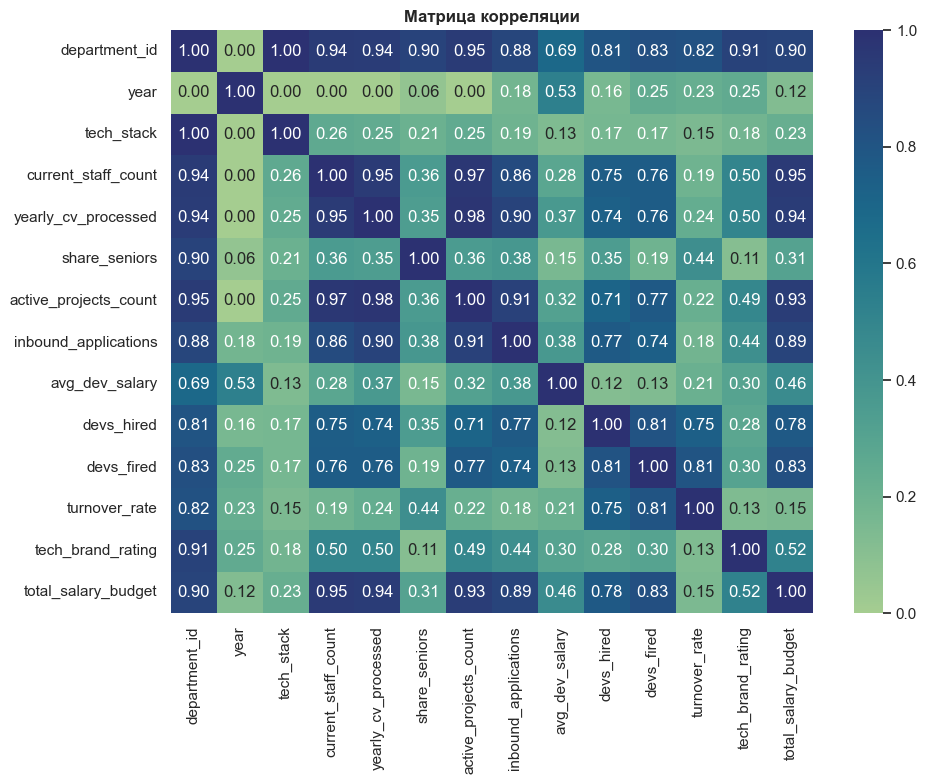

In [32]:
corr_matrix = data.phik_matrix(interval_cols=config.INTERVAL_COLS)
plot_correlation_heatmap(corr_matrix, 'Матрица корреляции')

Самое странное здесь - корреляция department_id с целевой переменной. Это просто порядковый номер. Получается, ложная корреляция. Этот признак в модель брать не будем

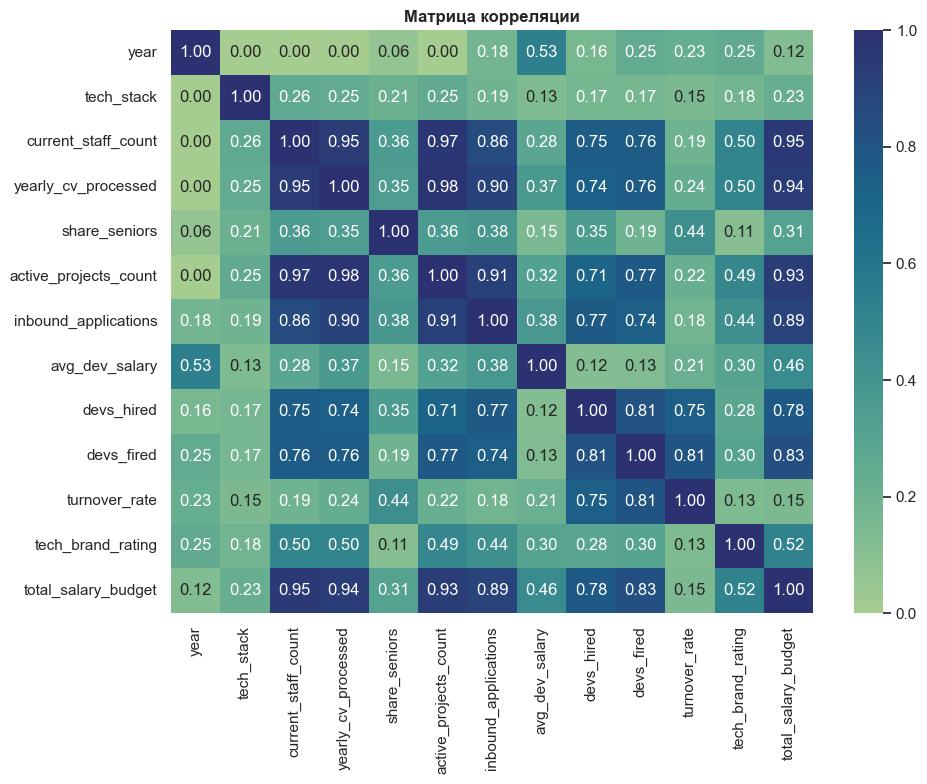

In [33]:
corr_matrix = data.drop(columns=['department_id']).phik_matrix(interval_cols=config.INTERVAL_COLS)
plot_correlation_heatmap(corr_matrix, 'Матрица корреляции')

Картина стала более логичной. На целевую переменную влияет больше всего количество активных проектов, количество сотрудников и бюджет на зарплаты

## Создание признаков

In [34]:
data['yearly_cv_processed_lag1'] = data.groupby('department_id')['yearly_cv_processed'].shift(1)
data.head(7)

,department_id,year,tech_stack,current_staff_count,yearly_cv_processed,share_seniors,active_projects_count,inbound_applications,avg_dev_salary,devs_hired,devs_fired,turnover_rate,tech_brand_rating,total_salary_budget,yearly_cv_processed_lag1
0,1000000.0,2020.0,Стадион,392.0,5847.0,4.591837,231.0,1969.0,110277.784723,77.0,52.0,0.329082,0.6,51877245.0,NaN
1,1000000.0,2021.0,Стадион,445.0,6688.0,6.292135,258.0,2415.0,123862.871896,119.0,47.0,0.373034,0.6,66162037.0,5847.0
2,1000000.0,2022.0,Стадион,514.0,7503.0,7.198444,291.0,2544.0,122932.673766,143.0,60.0,0.394942,0.6,75827728.0,6688.0
3,1000000.0,2023.0,Стадион,587.0,8272.0,8.858603,327.0,3426.0,123735.907223,103.0,63.0,0.282794,0.8,87165251.0,7503.0
4,1000000.0,2024.0,Стадион,632.0,9267.0,11.550633,362.0,3318.0,141861.433957,91.0,96.0,0.295886,0.2,107592482.0,8272.0
5,1000001.0,2020.0,Торговый_центр,441.0,7056.0,9.297052,252.0,3565.0,145355.242107,80.0,24.0,0.235828,0.8,76925251.0,NaN
6,1000001.0,2021.0,Торговый_центр,510.0,7918.0,8.823529,290.0,3904.0,134199.878106,95.0,55.0,0.294118,0.8,82128749.0,7056.0


In [35]:
data['active_projects_count_lag1'] = data.groupby('department_id')['active_projects_count'].shift(1)
data['active_projects_delta1'] = data.groupby('department_id')['active_projects_count'].diff(1)

In [36]:
data['cv_per_project'] = data['yearly_cv_processed'] / (data['active_projects_count'] + 1)
data['net_hiring'] = data['devs_hired'] - data['devs_fired']
data['cv_per_staff'] = data['yearly_cv_processed'] / (data['current_staff_count'] + 1)

## Созданные признаки

**Лаговые признаки** - значения переменных за прошлый год:
- `yearly_cv_processed_lag1`
- `active_projects_count_lag1`

**`active_projects_delta1`** — прирост активных проектов за год.
Два департамента могут иметь одинаковое количество проектов в прошлом году,
но разную динамику - один растёт, другой сокращается. Дельта даёт модели
информацию о направлении изменений, которой нет в лаге.

**`net_hiring`** - нанято минус уволено. Отражает реальный чистый прирост
штата департамента. `devs_hired` и `devs_fired` по отдельности менее
информативны - важен итоговый баланс.

**`cv_per_project`** и **`cv_per_staff`** - созданы для анализа,
но в модель не вошли: содержат `yearly_cv_processed` в числителе,
что создаёт утечку данных.

**Итоговые признаки модели:**
`yearly_cv_processed_lag1`, `active_projects_count_lag1`,
`active_projects_delta1`, `net_hiring`, `tech_brand_rating`, `tech_stack` (OHE)

In [37]:
features_to_check = [
    'yearly_cv_processed_lag1',
    'active_projects_count_lag1',
    'active_projects_delta1',
    'net_hiring',
    'tech_brand_rating',
]

results_df = pd.DataFrame({
    'feature': features_to_check,
    'correlation': [data[f].corr(data['yearly_cv_processed']) for f in features_to_check],
}).sort_values('correlation', ascending=False)

results_df

,feature,correlation
0,yearly_cv_processed_lag1,0.988865
1,active_projects_count_lag1,0.964687
4,tech_brand_rating,0.559473
2,active_projects_delta1,0.373096
3,net_hiring,0.159225


# Общий вывод по ноутбуку

Датасет содержал небольшое количество пропусков в 10 из 14 колонок. Пропуски заполнены медианой по департаменту. Отдельно были восстановлены значения devs_fired для департамента 1000456.

Обнаружены и исправлены аномальные выбросы в inbound_applications. Скорректирован turnover_rate. Пересчитали как (devs_hired + devs_fired) / current_staff_count

Целевая переменная растет с 2020 по 2024, однако тренд затухающий. Прирост снизился с 5,2% до 1,3% в год.

Ключевые признаки active_project_count, current_staff_count, total_salary_budget.

На уровне одного департамента - всего 5 точек временного ряда.

Целевая переменная `yearly_cv_processed` растёт с 2020 по 2024,
но темп затухающий: +5.2% в 2021 → +1.3% в 2024

Наибольшее влияние на целевую: количество активных проектов,
численность персонала, бюджет на зарплаты
